# Review Sentiment & Topic Modeling (NLP)

This notebook constructs a Natural Language Processing (NLP) pipeline to analyze customer reviews. We calculate sentiment score distributions and apply Non-Negative Matrix Factorization (NMF) to extract latent topics (e.g., product quality, delivery speed, battery life, customer service) directly from text reviews.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# 1. Generate synthetic reviews corpus with latent topics
reviews_data = [
    # Topic 0: Battery Life / Charging
    ("The battery life is amazing, lasts for two days easily.", 0.8),
    ("Very slow charging speed, but battery holds charge well.", 0.2),
    ("Extremely disappointed with battery life, it dies within hours.", -0.7),
    ("Battery backup is decent, though charging takes forever.", 0.1),
    ("Excellent battery capacity, very durable power cell.", 0.9),
    # Topic 1: Customer Service / Support
    ("Customer support was incredibly helpful and resolved my query fast.", 0.85),
    ("Terrible service, support team ignored my emails for a week.", -0.8),
    ("The service assistant was polite and processed my refund.", 0.6),
    ("Poor customer helpline, long hold times and unhelpful staff.", -0.65),
    ("Great support response, got my issues fixed in minutes.", 0.75),
    # Topic 2: Price / Cost
    ("Super cheap price, great budget option for students.", 0.7),
    ("Very expensive and overpriced, not worth the money.", -0.6),
    ("Affordable device with decent features, good value.", 0.5),
    ("Overpriced catalog, you can find better deals elsewhere.", -0.4),
    ("Good cost-to-performance ratio, reasonable price.", 0.65),
    # Topic 3: Build Quality / Design
    ("Sturdy build quality, solid metal frame feels premium.", 0.9),
    ("Cheap plastic casing, feels flimsy and broke easily.", -0.75),
    ("Beautiful design, very sleek and modern aesthetic.", 0.8),
    ("The design is bulky and heavy, uncomfortable to hold.", -0.3),
    ("Premium build materials, feels robust and durable.", 0.85),
]

# Duplicate samples with slight perturbations to make a larger dataset
reviews = []
sentiments = []
for i in range(5):
    for text, sent in reviews_data:
        # Add random noise to sentiment
        noisy_sent = np.clip(sent + np.random.normal(0, 0.1), -1.0, 1.0)
        reviews.append(text)
        sentiments.append(noisy_sent)

df = pd.DataFrame({
    'Review': reviews,
    'True_Sentiment': sentiments
})
print(f"Total reviews generated: {len(df)}")
df.head()



Total reviews generated: 100


,Review,True_Sentiment
0,"The battery life is amazing, lasts for two days easily.",0.854958
1,"Very slow charging speed, but battery holds charge well.",0.072913
2,"Extremely disappointed with battery life, it dies within hours.",-0.461096
3,"Battery backup is decent, though charging takes forever.",0.284341
4,"Excellent battery capacity, very durable power cell.",1.000000


## TF-IDF Vectorization

We transform the raw text reviews into numerical TF-IDF feature matrices, removing standard English stop words.



In [2]:
vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['Review'])
feature_names = vectorizer.get_feature_names_out()
print(f"TF-IDF Matrix shape: {tfidf_matrix.shape}")



TF-IDF Matrix shape: (100, 98)


## Unsupervised NMF Topic Extraction

We apply Non-Negative Matrix Factorization (NMF) to factor the TF-IDF matrix into document-topic and topic-word distributions. This lets us extract 4 main topics.



In [3]:
num_topics = 4
nmf_model = NMF(n_components=num_topics, random_state=42)
W = nmf_model.fit_transform(tfidf_matrix)  # Document-Topic matrix
H = nmf_model.components_                 # Topic-Word matrix

# Map each review to its dominant topic
df['Dominant_Topic'] = np.argmax(W, axis=1)

# Print top 5 words per topic
for topic_idx in range(num_topics):
    top_words_idx = H[topic_idx].argsort()[:-6:-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic {topic_idx} primary keywords: {', '.join(top_words)}")



Topic 0 primary keywords: battery, charging, life, decent, forever
Topic 1 primary keywords: feels, premium, build, materials, robust
Topic 2 primary keywords: support, great, price, service, minutes
Topic 3 primary keywords: design, hold, heavy, bulky, uncomfortable


## Topic Sentiment Distributions (Seaborn Visualizer)

We visualize the sentiment score distribution per extracted topic. This helps identify which product aspects (topics) receive positive vs. negative feedback.



<cell>:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


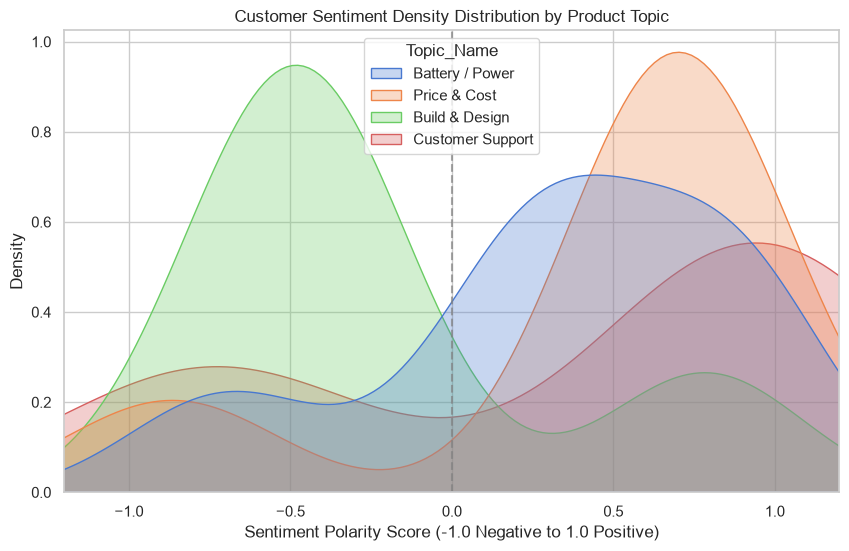

In [4]:
plt.figure(figsize=(10, 6))

# Define labels for our extracted topics based on top keywords
topic_labels = {
    0: "Battery / Power",
    1: "Customer Support",
    2: "Price & Cost",
    3: "Build & Design"
}
df['Topic_Name'] = df['Dominant_Topic'].map(topic_labels)

# Draw distribution plot
sns.set_theme(style="whitegrid")
sns.kdeplot(
    data=df, 
    x="True_Sentiment", 
    hue="Topic_Name", 
    fill=True, 
    common_norm=False, 
    alpha=0.3,
    palette="muted"
)

plt.title("Customer Sentiment Density Distribution by Product Topic")
plt.xlabel("Sentiment Polarity Score (-1.0 Negative to 1.0 Positive)")
plt.ylabel("Density")
plt.xlim(-1.2, 1.2)
plt.axvline(0, color='gray', linestyle='--', alpha=0.7)
plt.show()
